In [204]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
from statsmodels.regression.linear_model import OLS

In [205]:
from src import *

In [206]:
df_neg = pd.read_excel('Project data sheet_MS25002_A.xlsx',
                      sheet_name='neg_my', index_col=0, header=None)
df_neg = df_neg.T
df_neg.index = df_neg.iloc[:, :3].astype(str).agg('&'.join, axis=1)


In [207]:
df_neg.columns = ['Exp',  'Detail',  'Time',  'Cholesterylsulfate ',  'Nervonic acid ',  'Erucic acid ',  'Eicosenoic acid ',  'Docosatetranoic acid ',  'Dihomolinoleic acid ',  'Eicosadienoic acid ',  'Docosapentanoic acid ',
 'Stearic acid ',  'Docosahexanoic acid ',  'Linoleic acid ',  'Oleic acid ',  'Arachidonic acid ',  'Linolenic acid ',  'Indoxyl sulfate ',  'Palmitoleic acid ',  'Palmitic acid ',  'Pentadecanoic acid ',  'Myristic acid ',  'Lauric acid (dodecanoic acid) ',
 '4-Pyridoxic acid ',  'Panthenol ',  'Methylthioadenosine ',  'Thymidine (Deoxy) ',  'Uracil ',  'Pyridoxal ',  'Deoxyuridine ',  '2-O-Methylinosine ',  'Adenine ',  'Uridine ',  'Creatinine ',  'Hypoxanthine ',
 'Pyruvate ',  'Allantoin ',  'Hippuric acid ',  'Xanthine ',  '3-(4-Hydroxyphenyl)lactate ',  'N-Acetylmethionine ',  'Inosine ',  'Guanine ',  'Ribitol ',  'Cytidine ',  'Arabitol ',  'Phenylalanine ',  'Tryptophan ',  'Leucine ',
 '3-Hydroxybutyric acid ',  'Lactate ',   'Guanosine ',  'Orotic acid ',  'Isoleucine ',  'Fructose ',  'Pantothenic acid ',  '4-Acetamidobutyric acid ',  'Valine ',  'Tyrosine ',  'Glucose ',  'Taurine ',  'Glycerate ',  'S-Sulfocyteine ',  'Xanthosine ',
 'Orotidine ',  'Hypotaurine ',  'N-a-Acetyllysine ',  'Alanine ',  'Creatine ',  'Methylglutarate ',  'Threonine ',  'Uric Acid ',  'N-Acetylornithine ',  'N-Glycosyltaurine ',  'Glutamine ',  'Serine ',  'gamma-Glutamylmethionine ',
 'Asparagine ',  'S-Adenosylhomocysteine ',  'N-Acetylneuraminic acid ',  'Cysteic acid ',  '3-Hydroxy-3-methylglutaric acid ',  'alpha-Ketoglutarate ',  'Citrulline ',  'Cysteinsulfinate/Sulfinoalanine ',  'Fumarate ',  'Erythrose-4-phosphate ',
 'Glucuronic acid ',  'Succinate ',  'N-Acetylglutamate ',  'Citramalic acid ',  'Dimethylglycine ',  'Itaconate Iso1 ',  'Glutamate ',  'N-Acetylaspartate ',  'Carnosine ',  'Adenosine monophosphate, 3- ',  'Aspartate ',  'Malate ',  '2-Aminoadipic acid ',
 'Glutamylthreonine ',  'Glycerophosphorylserine ',  'Acetyl-CoA ',  'Adenosine monophosphate ',  'Glycerol-3-phosphate ',  'Glutamylglutamine ',
 'Nicotinamidedinucleotide ',  'Dihydroxyacetonephosphate ',   'Cystine ',  'UDP N-Acetylglucosamine ',  'Dimethylarginine ',  'Uridine monophosphate ',
 'N-Acetylglucosamine-1-phosphate ',  'Phosphate ',  'Pyrophosphate ',  'CDP-Ethanolamine ',  'Cystathionine ',  'Glyceraldehyde-3-phosphate ',  'Creatinephosphate ',   'Saccharopine ', 'N-Acetylglucosamine-6-phosphate ',  'N-Acetylaspartylglutamate ',
 'UDP glucose ',  'Phosphoethanolamine ',  'Cytidine monophosphate ',  'Adenosine diphosphate ',  'Glucose-6-phosphate ',  '2-Phosphoglycerate ',
 'Phosphoenolpyruvate ',  'Seduheptulose-7-phosphate ',  '3-Phosphoglycerate ',   'Citrate ',  'Argininosuccinate ',  'Uridine diphosphate ',
 '2-Hydroxyglutaric acid ',  'Fructose-6-phosphate ',  'Adenosine triphosphate ',  'Cytidine diphosphate ',  'Arginine ',  'UDP-Glucuronic acid ',
 'beta-Citrylglutamate ',  'Guanosine diphosphate ',  '6-Phosphogluconic acid ',  'Uridine triphosphate ',  'Nicotinamidedinucleotidephosphate ',  'Glutathione oxidised ',
 'Lysine ',  'Cytidine triphosphate ',   'Guanosine triphosphate ', 'Fructose-1,6-bisphosphate ']

In [208]:
df_neg.columns = df_neg.columns.str.strip()
df_neg.head(1)

,Exp,Detail,Time,Cholesterylsulfate,Nervonic acid,Erucic acid,Eicosenoic acid,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,...,beta-Citrylglutamate,Guanosine diphosphate,6-Phosphogluconic acid,Uridine triphosphate,Nicotinamidedinucleotidephosphate,Glutathione oxidised,Lysine,Cytidine triphosphate,Guanosine triphosphate,"Fructose-1,6-bisphosphate"
"VC, BaP&0.2% DMSO&24h","VC, BaP",0.2% DMSO,24h,0.315037,0.021629,0.300033,0.13318,0.030473,0.343176,0.130287,...,0.211489,0.007947,0.059466,0.019892,0.001603,0.000064,0.157026,0.000978,0.01466,0.0585


In [209]:
df_pos = pd.read_excel('Project data sheet_MS25002_A.xlsx', sheet_name='pos_my', index_col=0, header=None)
df_pos = df_pos.T
df_pos.index = df_pos.iloc[:, :3].astype(str).agg('&'.join, axis=1)

In [210]:
df_pos.columns = ['Exp',  'Detail',  'Time',  'Erucamide ',  'Linoleoylglycerol ',  'Oleoylglycerol ',  'Stearoylcarnitine (C18:0) ',  'Arachidonoylcarnitine (C20:4) ',  'Palmitoylcarnitine (C16:0) ',
 'Linoleylcarnitine (C18:2) ', 'Oleylcarnitine (C18:1) ', 'Myristoylcarnitine (C14:0) ', 'Palmitoleylcarnitine (C16:1) ', 'Nicotinamide ', 'Urocanic acid cis ', '4-Acetamidobutyric acid ', '4-Pyridoxic acid ',
 'Pyridoxal ', 'Urea ', 'Pantothenic acid ', 'Hexanoylcarnitine (C6) ', 'Adenine ', 'Hypoxanthine ', 'Creatinine ', 'Adenosine ', 'Valerylcarnitine (C5) ', 'Choline ', 'Butyrylcarnitine (C4) ', 'Riboflavin ',
 'Cytosine ',  'Inosine ',  'Trimethylamineoxid ', 'Guanine ', 'Propionylcarnitine (C3) ', '5-Aminovaleric acid betaine ', 'Cytidine ', 'Thiazolidine-4-carboxylic acid ', 'Phenylethanolamine ', 'Phenylalanine ',
 'Tryptophan ', 'Leucine ', 'Acetylcarnitine (C2) ', 'Guanosine ', 'N-Acetylputrescine ', 'Betaine ', 'Isoleucine ', 'gamma-Butyrobetaine/deoxycarnitine ', 'Thiamine ', 'Methionine ', 'Methyladenosine ', 'Dimethylglycine ',
 'Prolylleucine ', 'Valine ', 'Proline ', 'Octopamine iso1 P- ', 'Tyrosine ', 'Taurine ', 'Carnitine ', 'Prolylisoleucine ', 'Cysteine-S-sulfate ', 'Hypotaurine ', 'Alanine ', 'Creatine ', 'Glutamyleucine ', '5,6-Dihydrouracil iso1 ',
 'Threonine ', 'Glutamylisoleucine ', 'Glutamylphenylalanine ', '5,6-Dihydrouracil iso2 ', 'Glycine ', 'N-Acetylaspartylglutamate ', 'Homolysine ', '2-Aminoadipic acid ', 'Methioninesulfoxide ', 'Glutamine ',
 'Glutamylmethionine ', 'Serine ', 'Glycerophospoglycerol ', 'Asparagine ', 'Glycerophosphorylcholine ', 'beta-Citrylglutamate ', 'S-Adenosylhomocysteine ', 'Glutamic acid ', 'Citrulline ',
 'N-Methylhistidine ',  'Glycerophosphorylethanolamine ', 'N-Acetylspermidine ', 'N-Acetylneuraminic acid ', 'Dimethylarginine assymetric ', 'Ophthalmic acid ', 'Glutathione ', 'Aspartic acid ', 'Trimethyllysine ',
 'Histidine ', 'N-Methyllysine ', 'Homoarginine ', '1(3)-Methylhistidine ', 'Arginine ', 'Pipecolic acid ', 'Lysine ', 'Carnosine ', 'Ornithine ', 'Glutamylglutamine ', 'Flavine adenine dinucleotide ', 'S-Adenosylmethionine ',
 'Nicotinamidedinucleotide ', 'Saccharopine ', 'Cystathionine ', 'Glycerophosphorylinositol ', 'CDP-choline ', 'Cystine ', 'CDP-ethanolamine ', 'Argininosuccinate ','UDP N-Acetylglucosamine ', 'Glutathione oxidised ']

In [211]:
df_pos.columns = df_pos.columns.str.strip()
df_pos.columns

Index(['Exp', 'Detail', 'Time', 'Erucamide', 'Linoleoylglycerol',
       'Oleoylglycerol', 'Stearoylcarnitine (C18:0)',
       'Arachidonoylcarnitine (C20:4)', 'Palmitoylcarnitine (C16:0)',
       'Linoleylcarnitine (C18:2)',
       ...
       'Nicotinamidedinucleotide', 'Saccharopine', 'Cystathionine',
       'Glycerophosphorylinositol', 'CDP-choline', 'Cystine',
       'CDP-ethanolamine', 'Argininosuccinate', 'UDP N-Acetylglucosamine',
       'Glutathione oxidised'],
      dtype='object', length=115)

In [212]:
df_key = df_pos[['Exp',  'Detail',  'Time']]

In [213]:
sorted(df_pos.columns)

['1(3)-Methylhistidine',
 '2-Aminoadipic acid',
 '4-Acetamidobutyric acid',
 '4-Pyridoxic acid',
 '5,6-Dihydrouracil iso1',
 '5,6-Dihydrouracil iso2',
 '5-Aminovaleric acid betaine',
 'Acetylcarnitine (C2)',
 'Adenine',
 'Adenosine',
 'Alanine',
 'Arachidonoylcarnitine (C20:4)',
 'Arginine',
 'Argininosuccinate',
 'Asparagine',
 'Aspartic acid',
 'Betaine',
 'Butyrylcarnitine (C4)',
 'CDP-choline',
 'CDP-ethanolamine',
 'Carnitine',
 'Carnosine',
 'Choline',
 'Citrulline',
 'Creatine',
 'Creatinine',
 'Cystathionine',
 'Cysteine-S-sulfate',
 'Cystine',
 'Cytidine',
 'Cytosine',
 'Detail',
 'Dimethylarginine assymetric',
 'Dimethylglycine',
 'Erucamide',
 'Exp',
 'Flavine adenine dinucleotide',
 'Glutamic acid',
 'Glutamine',
 'Glutamyleucine',
 'Glutamylglutamine',
 'Glutamylisoleucine',
 'Glutamylmethionine',
 'Glutamylphenylalanine',
 'Glutathione',
 'Glutathione oxidised',
 'Glycerophosphorylcholine',
 'Glycerophosphorylethanolamine',
 'Glycerophosphorylinositol',
 'Glycerophospogly

In [214]:
drop_pos = ['4-Pyridoxic acid','beta-Citrylglutamate', 'Dimethylglycine', 'Hypotaurine', 'Inosine', 'N-Acetylneuraminic acid', 'Pyridoxal',  'Saccharopine'  ]
#df_pos.drop(drop_pos, axis=1, inplace=True)
drop_neg = sorted(set(df_pos.columns).intersection(set(df_neg.columns)))

In [215]:
df_neg.drop(drop_neg, axis=1, inplace=True)

In [216]:
#df_neg['P/N'] = 'negative mode'

In [217]:
df = pd.concat([df_key, df_neg.iloc[:,3:], df_pos.iloc[:,3:] ], axis=1)

In [218]:
sorted(df.columns.to_list())

['1(3)-Methylhistidine',
 '2-Aminoadipic acid',
 '2-Hydroxyglutaric acid',
 '2-O-Methylinosine',
 '2-Phosphoglycerate',
 '3-(4-Hydroxyphenyl)lactate',
 '3-Hydroxy-3-methylglutaric acid',
 '3-Hydroxybutyric acid',
 '3-Phosphoglycerate',
 '4-Acetamidobutyric acid',
 '4-Pyridoxic acid',
 '5,6-Dihydrouracil iso1',
 '5,6-Dihydrouracil iso2',
 '5-Aminovaleric acid betaine',
 '6-Phosphogluconic acid',
 'Acetyl-CoA',
 'Acetylcarnitine (C2)',
 'Adenine',
 'Adenosine',
 'Adenosine diphosphate',
 'Adenosine monophosphate',
 'Adenosine monophosphate, 3-',
 'Adenosine triphosphate',
 'Alanine',
 'Allantoin',
 'Arabitol',
 'Arachidonic acid',
 'Arachidonoylcarnitine (C20:4)',
 'Arginine',
 'Argininosuccinate',
 'Asparagine',
 'Aspartate',
 'Aspartic acid',
 'Betaine',
 'Butyrylcarnitine (C4)',
 'CDP-Ethanolamine',
 'CDP-choline',
 'CDP-ethanolamine',
 'Carnitine',
 'Carnosine',
 'Choline',
 'Citramalic acid',
 'Citrate',
 'Citrulline',
 'Creatine',
 'Creatinephosphate',
 'Creatinine',
 'Cystathionin

In [219]:
#df.columns = df.columns.str.strip().str.lower()
#df = df.loc[:, ~df.columns.duplicated()]

In [220]:
#df[df.columns[df.columns.duplicated()]]#.reindex(sorted(df.loc[:, ~df.columns.duplicated()].columns), axis=1)

In [221]:
df.index = df.index.to_series().astype(str)+ ' | ' + pd.Series(range(len(df)), index=df.index).astype(str)


In [222]:
df.head(1)

,Exp,Detail,Time,Eicosenoic acid,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,Docosapentanoic acid,Stearic acid,Docosahexanoic acid,...,Nicotinamidedinucleotide,Saccharopine,Cystathionine,Glycerophosphorylinositol,CDP-choline,Cystine,CDP-ethanolamine,Argininosuccinate,UDP N-Acetylglucosamine,Glutathione oxidised
"VC, BaP&0.2% DMSO&24h | 0","VC, BaP",0.2% DMSO,24h,0.13318,0.030473,0.343176,0.130287,0.034168,4.998801,0.213494,...,0.002042,0.007606,0.045273,0.005891,0.001439,0.184889,0.000885,0.011639,0.000352,0.000004


In [223]:
df[df.columns[4:]] = df[df.columns[4:]].apply(pd.to_numeric, errors='coerce')

In [224]:
df.columns

Index(['Exp', 'Detail', 'Time', 'Eicosenoic acid', 'Docosatetranoic acid',
       'Dihomolinoleic acid', 'Eicosadienoic acid', 'Docosapentanoic acid',
       'Stearic acid', 'Docosahexanoic acid',
       ...
       'Nicotinamidedinucleotide', 'Saccharopine', 'Cystathionine',
       'Glycerophosphorylinositol', 'CDP-choline', 'Cystine',
       'CDP-ethanolamine', 'Argininosuccinate', 'UDP N-Acetylglucosamine',
       'Glutathione oxidised'],
      dtype='object', length=216)

In [225]:
metadata_cols = ['Exp', 'Detail', 'Time']
meta = df[metadata_cols].copy()
meta.columns = ['exp', 'detail', 'time']
meta['Group'] = meta['exp'] + ' | ' + meta['detail'] + ' | ' + meta['time']
meta

,exp,detail,time,Group
"VC, BaP&0.2% DMSO&24h | 0","VC, BaP",0.2% DMSO,24h,"VC, BaP | 0.2% DMSO | 24h"
"VC, BaP&0.2% DMSO&24h | 1","VC, BaP",0.2% DMSO,24h,"VC, BaP | 0.2% DMSO | 24h"
"VC, BaP&0.2% DMSO&24h | 2","VC, BaP",0.2% DMSO,24h,"VC, BaP | 0.2% DMSO | 24h"
BaP&20µM BaP&24h | 3,BaP,20µM BaP,24h,BaP | 20µM BaP | 24h
BaP&20µM BaP&24h | 4,BaP,20µM BaP,24h,BaP | 20µM BaP | 24h
BaP&20µM BaP&24h | 5,BaP,20µM BaP,24h,BaP | 20µM BaP | 24h
BaP&2µM BaP&24h | 6,BaP,2µM BaP,24h,BaP | 2µM BaP | 24h
BaP&2µM BaP&24h | 7,BaP,2µM BaP,24h,BaP | 2µM BaP | 24h
BaP&2µM BaP&24h | 8,BaP,2µM BaP,24h,BaP | 2µM BaP | 24h
"VC, BBF&0.05% DMSO&24h | 9","VC, BBF",0.05% DMSO,24h,"VC, BBF | 0.05% DMSO | 24h"


In [226]:
df.head(2).T

,"VC, BaP&0.2% DMSO&24h | 0","VC, BaP&0.2% DMSO&24h | 1"
Exp,"VC, BaP","VC, BaP"
Detail,0.2% DMSO,0.2% DMSO
Time,24h,24h
Eicosenoic acid,0.13318,0.107953
Docosatetranoic acid,0.030473,0.023631
...,...,...
Cystine,0.184889,0.125613
CDP-ethanolamine,0.000885,0.000952
Argininosuccinate,0.011639,0.004513
UDP N-Acetylglucosamine,0.000352,0.001362


In [227]:
df.iloc[:,4:].head(2)

,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,Docosapentanoic acid,Stearic acid,Docosahexanoic acid,Linoleic acid,Oleic acid,Arachidonic acid,Linolenic acid,...,Nicotinamidedinucleotide,Saccharopine,Cystathionine,Glycerophosphorylinositol,CDP-choline,Cystine,CDP-ethanolamine,Argininosuccinate,UDP N-Acetylglucosamine,Glutathione oxidised
"VC, BaP&0.2% DMSO&24h | 0",0.030473,0.343176,0.130287,0.034168,4.998801,0.213494,0.469937,3.608541,0.264689,0.060413,...,0.002042,0.007606,0.045273,0.005891,0.001439,0.184889,0.000885,0.011639,0.000352,0.000004
"VC, BaP&0.2% DMSO&24h | 1",0.023631,0.251461,0.123798,0.031935,1.834485,0.202699,0.309275,2.684990,0.173167,0.053643,...,0.003216,0.002045,0.027190,0.003501,0.001128,0.125613,0.000952,0.004513,0.001362,0.000451


In [228]:
#check duplicates
mylist = df.iloc[:,5:-2].astype(float).columns.tolist()
dup = {x for x in mylist if mylist.count(x) > 1}
dup

set()

In [229]:
#kick correlated compounds
filtered_df, kicked_out_table = kick_high_corr(df.iloc[:,4:], threshold=0.90)

In [230]:
filtered_df.head(2)

,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,Docosapentanoic acid,Stearic acid,Oleic acid,Linolenic acid,Indoxyl sulfate,Palmitoleic acid,Myristic acid,...,Ornithine,Glutamylglutamine,Flavine adenine dinucleotide,S-Adenosylmethionine,Saccharopine,Cystathionine,Glycerophosphorylinositol,CDP-choline,Cystine,Argininosuccinate
"VC, BaP&0.2% DMSO&24h | 0",0.030473,0.343176,0.130287,0.034168,4.998801,3.608541,0.060413,0.021241,1.195753,0.213695,...,0.041754,0.057103,0.000091,0.151874,0.007606,0.045273,0.005891,0.001439,0.184889,0.011639
"VC, BaP&0.2% DMSO&24h | 1",0.023631,0.251461,0.123798,0.031935,1.834485,2.684990,0.053643,0.032912,0.657520,0.179010,...,0.040659,0.106731,0.000580,0.158903,0.002045,0.027190,0.003501,0.001128,0.125613,0.004513


In [231]:
#metabo = df.drop(columns=metadata_cols).copy()
filtered_df, kicked_out_table = kick_high_corr(df.iloc[:,4:], threshold=0.90)
metabo = filtered_df.astype(float)
log_metabo =  np.log10(metabo + 1e-6)
log_metabo.to_csv('log_metab.csv')
scaler = MinMaxScaler()
scaled_metabo = pd.DataFrame(scaler.fit_transform(log_metabo), columns=log_metabo.columns, index=filtered_df.index)
scaled_metabo.to_csv('scaled.csv')

In [232]:
scaled_metabo.head(2)

,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,Docosapentanoic acid,Stearic acid,Oleic acid,Linolenic acid,Indoxyl sulfate,Palmitoleic acid,Myristic acid,...,Ornithine,Glutamylglutamine,Flavine adenine dinucleotide,S-Adenosylmethionine,Saccharopine,Cystathionine,Glycerophosphorylinositol,CDP-choline,Cystine,Argininosuccinate
"VC, BaP&0.2% DMSO&24h | 0",0.503175,0.445577,0.348206,0.249668,0.938914,0.614821,0.618401,0.235207,0.606076,0.875816,...,0.216551,0.618448,0.542228,0.866712,1.000000,1.000000,1.000000,0.783133,0.918980,0.884299
"VC, BaP&0.2% DMSO&24h | 1",0.394464,0.274374,0.325152,0.211803,0.866663,0.442220,0.559865,0.407945,0.457077,0.860107,...,0.204412,0.796333,0.837102,0.882798,0.565382,0.815412,0.744096,0.727455,0.800228,0.502261


In [233]:
#df['grupice'] = ['BaP',  'BaP', 'BaP',  'BaP',  'BaP',  'BaP',  'BaP',  'BaP',  'BaP',   'BBF', 'BBF', 'BBF',
# 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BaP', 'BaP', 'BaP', 'BaP', 'BaP', 'BaP', 'BaP', 'BaP', 'BaP',
# 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BBF', 'BBF']


In [234]:
#df['Group'] = df.grupice + '_' + df.time
#df['Group']

In [235]:
data = log_metabo.copy()
data['Group'] = meta.Group  # preserve your Group as a column

In [236]:
meta_parts = data['Group'].str.split('|', expand=True)
meta = pd.DataFrame({
    'Exp': meta_parts[0].str.strip(),
    'Detail': meta_parts[1].str.strip(),
    'Time': meta_parts[2].str.strip()
})
meta['Exp_clean'] = meta['Exp'].str.replace("VC, ", "").str.strip()
meta['Pool'] = meta['Exp_clean'] + " | " + meta['Time']
meta['Group'] = data['Group']
data.drop('Group', axis=1, inplace=True)
meta

,Exp,Detail,Time,Exp_clean,Pool,Group
"VC, BaP&0.2% DMSO&24h | 0","VC, BaP",0.2% DMSO,24h,BaP,BaP | 24h,"VC, BaP | 0.2% DMSO | 24h"
"VC, BaP&0.2% DMSO&24h | 1","VC, BaP",0.2% DMSO,24h,BaP,BaP | 24h,"VC, BaP | 0.2% DMSO | 24h"
"VC, BaP&0.2% DMSO&24h | 2","VC, BaP",0.2% DMSO,24h,BaP,BaP | 24h,"VC, BaP | 0.2% DMSO | 24h"
BaP&20µM BaP&24h | 3,BaP,20µM BaP,24h,BaP,BaP | 24h,BaP | 20µM BaP | 24h
BaP&20µM BaP&24h | 4,BaP,20µM BaP,24h,BaP,BaP | 24h,BaP | 20µM BaP | 24h
BaP&20µM BaP&24h | 5,BaP,20µM BaP,24h,BaP,BaP | 24h,BaP | 20µM BaP | 24h
BaP&2µM BaP&24h | 6,BaP,2µM BaP,24h,BaP,BaP | 24h,BaP | 2µM BaP | 24h
BaP&2µM BaP&24h | 7,BaP,2µM BaP,24h,BaP,BaP | 24h,BaP | 2µM BaP | 24h
BaP&2µM BaP&24h | 8,BaP,2µM BaP,24h,BaP,BaP | 24h,BaP | 2µM BaP | 24h
"VC, BBF&0.05% DMSO&24h | 9","VC, BBF",0.05% DMSO,24h,BBF,BBF | 24h,"VC, BBF | 0.05% DMSO | 24h"


In [237]:
full_log = pd.concat([meta, data], axis=1)
full_log.head(1)
#valid_pools = full_log.groupby('Pool')['Group'].nunique().reset_index().rename(columns={'Group': 'n_groups'}).query('n_groups == 3')['Pool']
#valid_pools

,Exp,Detail,Time,Exp_clean,Pool,Group,Docosatetranoic acid,Dihomolinoleic acid,Eicosadienoic acid,Docosapentanoic acid,...,Ornithine,Glutamylglutamine,Flavine adenine dinucleotide,S-Adenosylmethionine,Saccharopine,Cystathionine,Glycerophosphorylinositol,CDP-choline,Cystine,Argininosuccinate
"VC, BaP&0.2% DMSO&24h | 0","VC, BaP",0.2% DMSO,24h,BaP,BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",-1.516073,-0.464482,-0.885096,-1.466373,...,-1.37929,-1.243336,-4.036611,-0.818514,-2.118772,-1.344151,-2.229707,-2.841766,-0.733088,-1.934042


In [238]:
cout = full_log[['Pool','Orotidine','Group']]
cout.groupby(['Pool', 'Group'])['Orotidine'].mean().sort_index()

Pool       Group                      
BBF | 24h  BBF | 20µM BBF | 24h          -2.924717
           BBF | 2µM BBF | 24h           -3.004513
           VC, BBF | 0.05% DMSO | 24h    -2.872752
BBF | 96h  BBF | 10µM BBF | 96h          -3.554714
           BBF | 1µM BBF | 96h           -3.102919
           VC, BBF | 0.025% DMSO | 96h   -2.376846
BaP | 24h  BaP | 20µM BaP | 24h          -3.079379
           BaP | 2µM BaP | 24h           -2.902624
           VC, BaP | 0.2% DMSO | 24h     -2.789421
BaP | 96h  BaP | 10µM BaP | 96h          -3.479037
           BaP | 1µM BaP | 96h           -2.442330
           VC, BaP | 0.1% DMSO | 96h     -2.455412
Name: Orotidine, dtype: float64

In [239]:
def run_anova_on_pooled_groups(data: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    full_log = pd.concat([meta, data], axis=1)
    valid_pools = full_log.groupby('Pool')['Group'].nunique().reset_index().rename(columns={'Group': 'n_groups'}).query('n_groups == 3')['Pool']
    anova_df = pd.DataFrame()
    for pool in valid_pools:
        anova_results = []
        subset = full_log[full_log['Pool'] == pool]
        for metabolite in data.columns:
            groups = [group_data[metabolite].values for _, group_data in subset.groupby('Group')]
            if all(len(g) > 1 for g in groups):
                stat, pval = f_oneway(*groups)
                anova_results.append({'Pool': pool, 'Metabolite': metabolite,'Raw_P': pval})

        anova_df_pool = pd.DataFrame(anova_results)
        anova_df_pool = anova_df_pool[anova_df_pool['Raw_P'].apply(lambda x: isinstance(x, (float, int)) and np.isfinite(x))].copy()
        anova_df_pool['FDR_P'] = (anova_df_pool.groupby('Pool')['Raw_P'].transform(lambda pvals: multipletests(pvals, method='fdr_bh')[1]))
        anova_df = pd.concat([anova_df_pool, 
                              anova_df], axis=0)
    return anova_df#.sort_values(['Pool', 'FDR_P'])

In [240]:
anova_df0 = run_anova_on_pooled_groups(data, meta)
anova_df = anova_df0[anova_df0['FDR_P']<0.05].sort_values('Metabolite')


In [241]:
anova_df

,Pool,Metabolite,Raw_P,FDR_P
120,BBF | 96h,2-Aminoadipic acid,0.001853,0.030474
100,BBF | 96h,Acetylcarnitine (C2),0.000573,0.014143
86,BaP | 96h,Adenine,0.002268,0.032141
143,BBF | 96h,Cystathionine,0.002905,0.043001
143,BaP | 96h,Cystathionine,0.000069,0.002647
38,BaP | 96h,Glucuronic acid,0.003649,0.045000
46,BaP | 24h,Glutamylthreonine,0.000022,0.003242
144,BaP | 96h,Glycerophosphorylinositol,0.000034,0.002516
144,BBF | 96h,Glycerophosphorylinositol,0.000075,0.005526
85,BBF | 96h,Hexanoylcarnitine (C6),0.000813,0.017187


In [242]:
fd = pd.concat([meta, data], axis=1)
fd['Docosatetranoic acid'].groupby(fd.Group).mean().sort_values(ascending=False)

Group
BBF | 10µM BBF | 96h          -1.266470
BaP | 10µM BaP | 96h          -1.308898
BBF | 2µM BBF | 24h           -1.428277
BaP | 20µM BaP | 24h          -1.434334
BBF | 20µM BBF | 24h          -1.453078
BaP | 2µM BaP | 24h           -1.461399
VC, BaP | 0.2% DMSO | 24h     -1.478634
VC, BBF | 0.05% DMSO | 24h    -1.504543
BBF | 1µM BBF | 96h           -1.526489
BaP | 1µM BaP | 96h           -1.648879
VC, BBF | 0.025% DMSO | 96h   -1.749096
VC, BaP | 0.1% DMSO | 96h     -1.883877
Name: Docosatetranoic acid, dtype: float64

In [243]:
import numpy as np
import pandas as pd
import itertools


log2fc_results = []
metadata_cols = ['Pool', 'Group', 'Exp', 'Detail', 'Time', 'Exp_clean']
metabolite_columns = [col for col in fd.columns if col not in metadata_cols]

log10_of_2 = np.log10(2)
for pool_name, pool_df in fd.groupby('Pool'):
    groups_in_pool = pool_df['Group'].unique()

    

    control_group_name = None
    treatment_group_names = []
    for g_name in groups_in_pool:
        if g_name.startswith("VC"):
            control_group_name = g_name
        else:
            treatment_group_names.append(g_name)

    if control_group_name is None:
        print(f"Warning: No control group (starting with 'VC') found in Pool '{pool_name}'. Skipping this pool.")
        continue

    if not treatment_group_names:
        print(f"Warning: No treatment groups found in Pool '{pool_name}' to compare with control '{control_group_name}'. Skipping.")
        continue

    control_data_log10_means = pool_df[pool_df['Group'] == control_group_name][metabolite_columns].mean()

    for treatment_group_name in treatment_group_names:
        treatment_data_log10_means = pool_df[pool_df['Group'] == treatment_group_name][metabolite_columns].mean()

        for metabolite in metabolite_columns:
            mean_log10_treatment = treatment_data_log10_means[metabolite]
            mean_log10_control = control_data_log10_means[metabolite]


            if pd.notna(mean_log10_treatment) and pd.notna(mean_log10_control):
                # Calculate log2FC from log10 means: (log10(T) - log10(C)) / log10(2)
                if log10_of_2 == 0:
                    log2fc = np.nan 
                else:
                    log2fc = (mean_log10_treatment - mean_log10_control) / log10_of_2
            else:
                # If either mean is NaN (e.g., all values for that metabolite in that group were NaN),
                # then log2FC is NaN.
                log2fc = np.nan

            log2fc_results.append({
                'Pool': pool_name,
                'Metabolite': metabolite,
                'Treatment_Group': treatment_group_name,
                'Control_Group': control_group_name,
                'Log2FC': log2fc
            })

log2fc_df = pd.DataFrame(log2fc_results)



In [244]:
log2fc_df.sort_values(['Metabolite', 'Pool']).head(10)

,Pool,Metabolite,Treatment_Group,Control_Group,Log2FC
120,BBF | 24h,2-Aminoadipic acid,BBF | 20µM BBF | 24h,"VC, BBF | 0.05% DMSO | 24h",0.035543
268,BBF | 24h,2-Aminoadipic acid,BBF | 2µM BBF | 24h,"VC, BBF | 0.05% DMSO | 24h",-0.099907
416,BBF | 96h,2-Aminoadipic acid,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-1.722708
564,BBF | 96h,2-Aminoadipic acid,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-1.354726
712,BaP | 24h,2-Aminoadipic acid,BaP | 20µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",0.218950
860,BaP | 24h,2-Aminoadipic acid,BaP | 2µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",-0.257471
1008,BaP | 96h,2-Aminoadipic acid,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-2.193748
1156,BaP | 96h,2-Aminoadipic acid,BaP | 1µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-0.751052
64,BBF | 24h,2-Hydroxyglutaric acid,BBF | 20µM BBF | 24h,"VC, BBF | 0.05% DMSO | 24h",-0.354294
212,BBF | 24h,2-Hydroxyglutaric acid,BBF | 2µM BBF | 24h,"VC, BBF | 0.05% DMSO | 24h",-0.010728


In [245]:
# Assuming log2fc_df and anova_df0 are already computed

# Merge the two dataframes
merged_df = pd.merge(log2fc_df, anova_df0, on=['Pool', 'Metabolite'], how='left')

# Select and rename columns for the final output
# 'Log2FC' comes from log2fc_df
# 'FDR_P' from anova_df0 will be renamed to 'FDR_Pval'
final_output_df = merged_df[['Metabolite', 'Log2FC', 'FDR_P', 'Pool']].copy()
final_output_df.rename(columns={'FDR_P': 'FDR_Pval'}, inplace=True)
final_output_df.to_csv('volcano.csv')

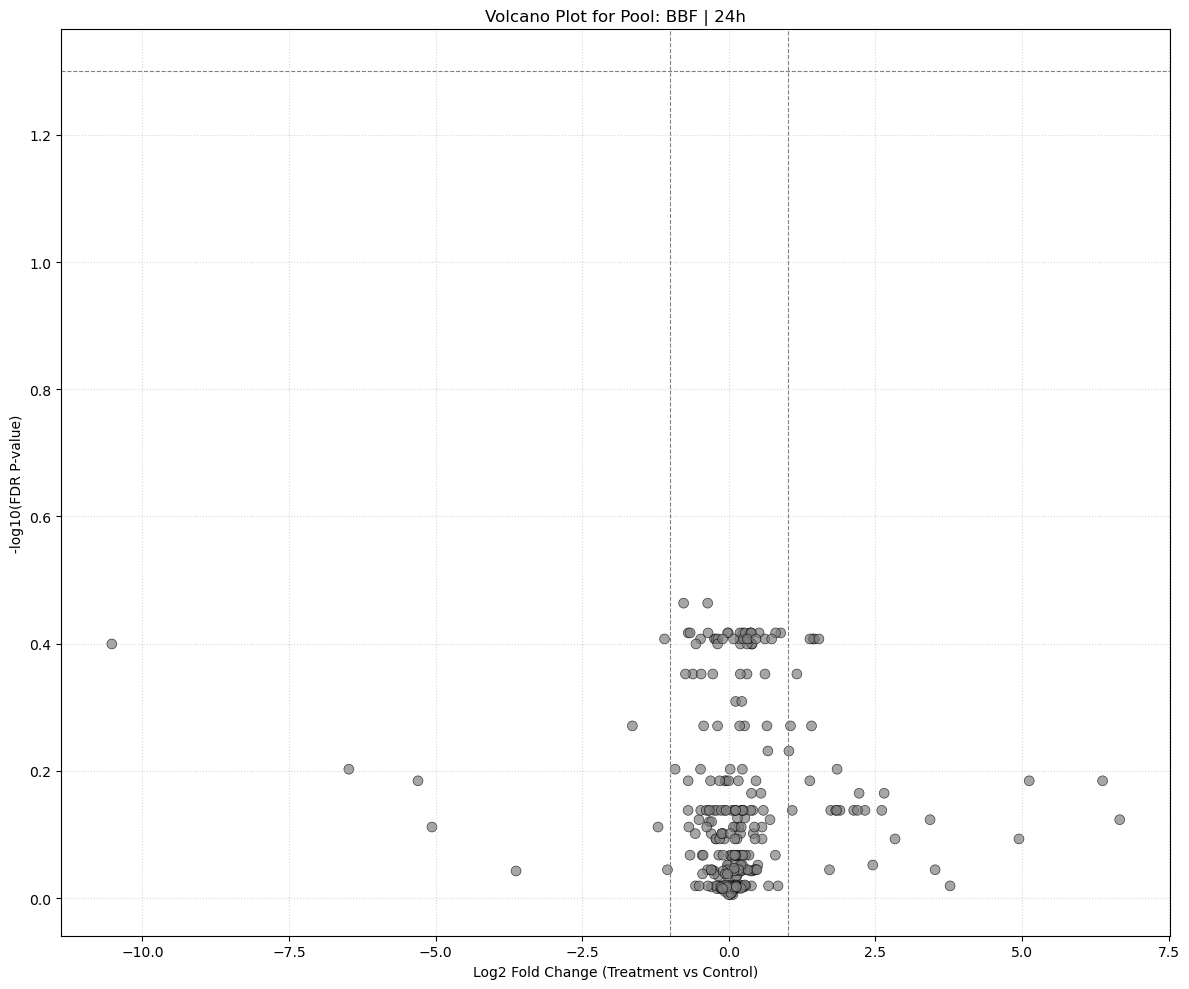

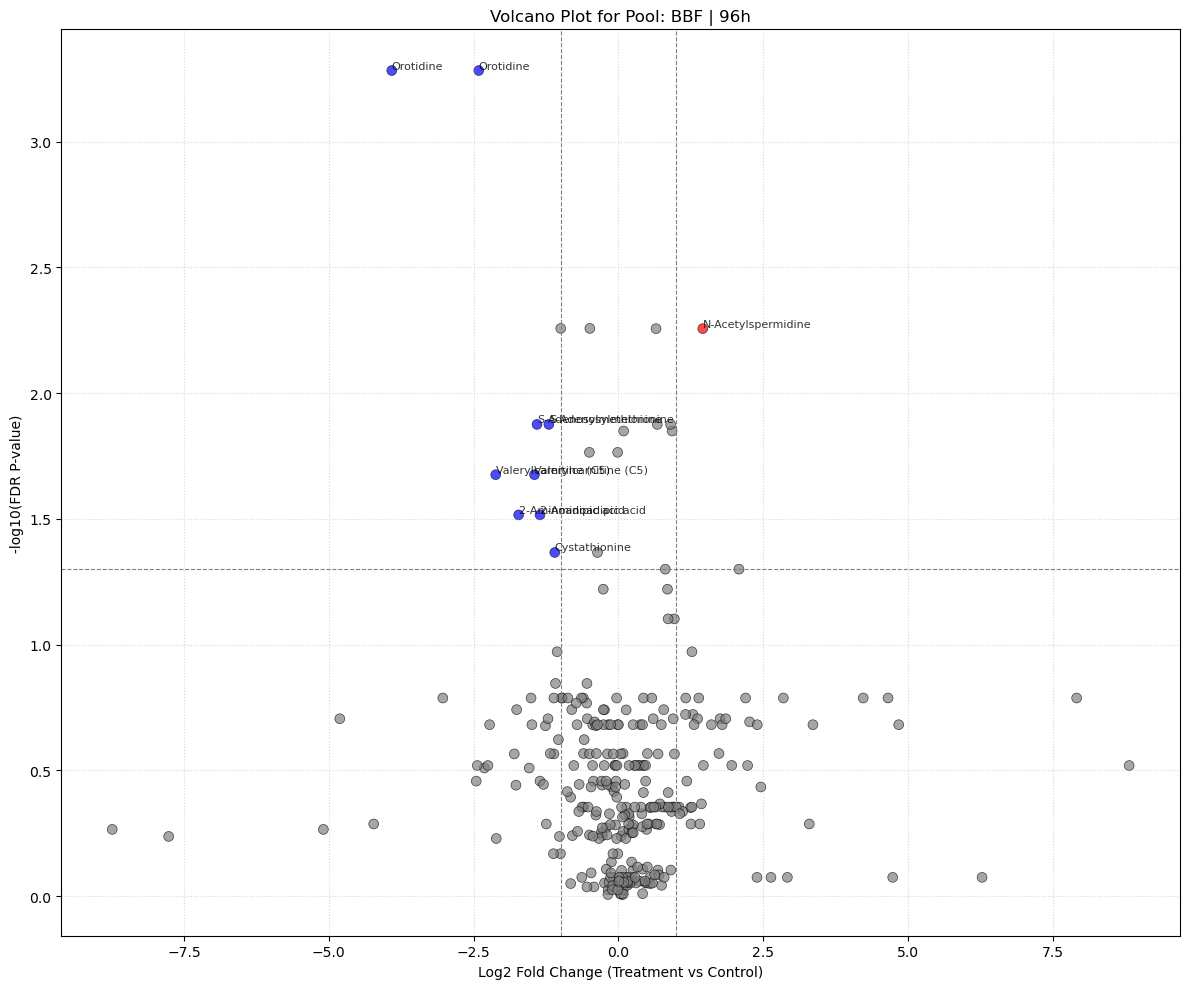

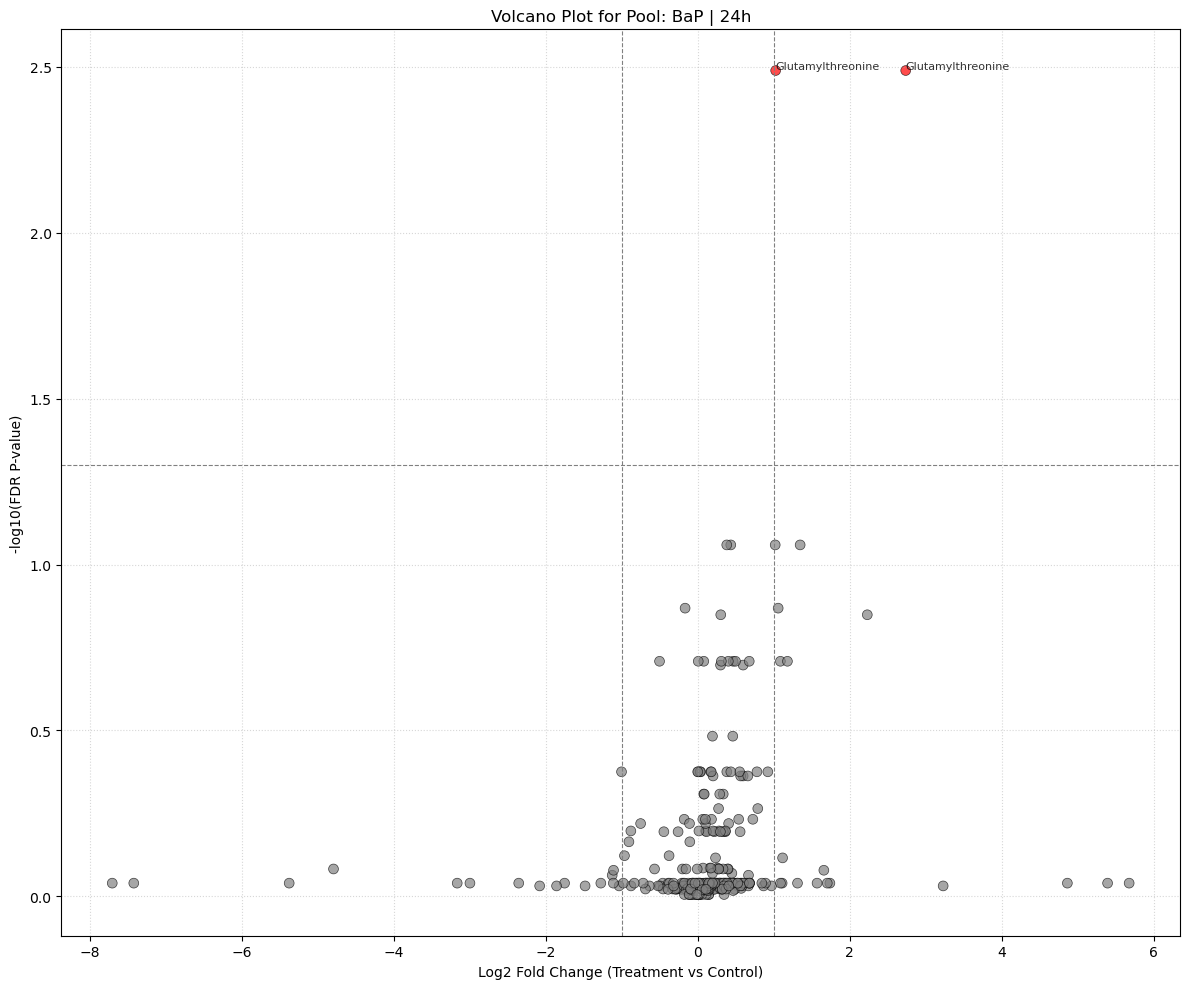

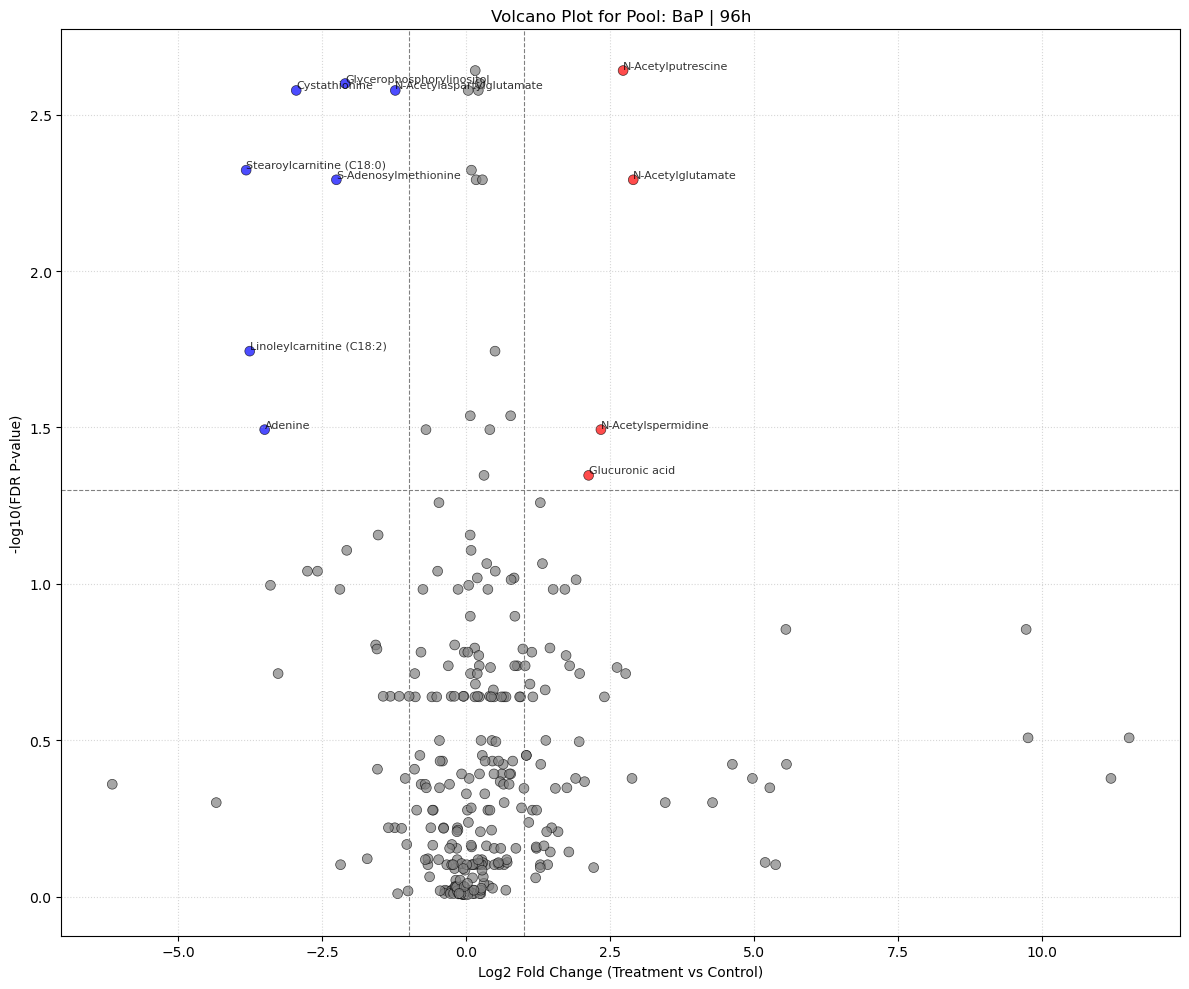

In [246]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming final_output_df is already computed and available
# It should have columns: 'Pool', 'Log2FC', 'FDR_Pval', 'Metabolite'

# Define significance thresholds
log2fc_threshold = 1.0  # Log2 fold change threshold (e.g., 1.0 for a 2-fold change)
pval_threshold = 0.05   # FDR adjusted p-value threshold

unique_pools = final_output_df['Pool'].unique()

for pool_name in unique_pools:
    pool_data = final_output_df[final_output_df['Pool'] == pool_name].copy()

    # Prepare data for plotting: calculate -log10(FDR_Pval)
    # Replace p-values of 0 with a very small number to avoid -inf results from log10(0)
    # and to ensure these highly significant points are plotted.
    pool_data['-log10_FDR_Pval'] = -np.log10(pool_data['FDR_Pval'].replace(0, 1e-300))

    # Drop rows where Log2FC or the calculated -log10_FDR_Pval is NaN
    pool_data.dropna(subset=['Log2FC', '-log10_FDR_Pval'], inplace=True)

    if pool_data.empty:
        print(f"No valid data to plot for Pool: {pool_name} after filtering.")
        continue

    # Determine point colors based on significance
    conditions = [
        (pool_data['Log2FC'] > log2fc_threshold) & (pool_data['FDR_Pval'] < pval_threshold),  # Significantly upregulated
        (pool_data['Log2FC'] < -log2fc_threshold) & (pool_data['FDR_Pval'] < pval_threshold), # Significantly downregulated
    ]
    color_choices = ['red', 'blue']  # Colors for upregulated, downregulated
    pool_data['color'] = np.select(conditions, color_choices, default='grey') # Default for non-significant

    # Create the volcano plot
    plt.figure(figsize=(12, 10)) # Increased figure size for better label visibility
    plt.scatter(pool_data['Log2FC'], pool_data['-log10_FDR_Pval'],
                c=pool_data['color'], alpha=0.7, edgecolors='k', linewidths=0.5, s=50)

    # Add threshold lines
    plt.axvline(x=log2fc_threshold, color='grey', linestyle='--', linewidth=0.8)
    plt.axvline(x=-log2fc_threshold, color='grey', linestyle='--', linewidth=0.8)
    plt.axhline(y=-np.log10(pval_threshold), color='grey', linestyle='--', linewidth=0.8)

    # Add labels and title
    plt.title(f'Volcano Plot for Pool: {pool_name}')
    plt.xlabel('Log2 Fold Change (Treatment vs Control)')
    plt.ylabel('-log10(FDR P-value)')
    plt.grid(True, linestyle=':', alpha=0.5)

    # Annotate significant points
    significant_points = pool_data[pool_data['color'] != 'grey']
    for _, row in significant_points.iterrows():
        plt.text(row['Log2FC'], row['-log10_FDR_Pval'], str(row['Metabolite']),
                 fontsize=8, ha='left', va='bottom', alpha=0.8)

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

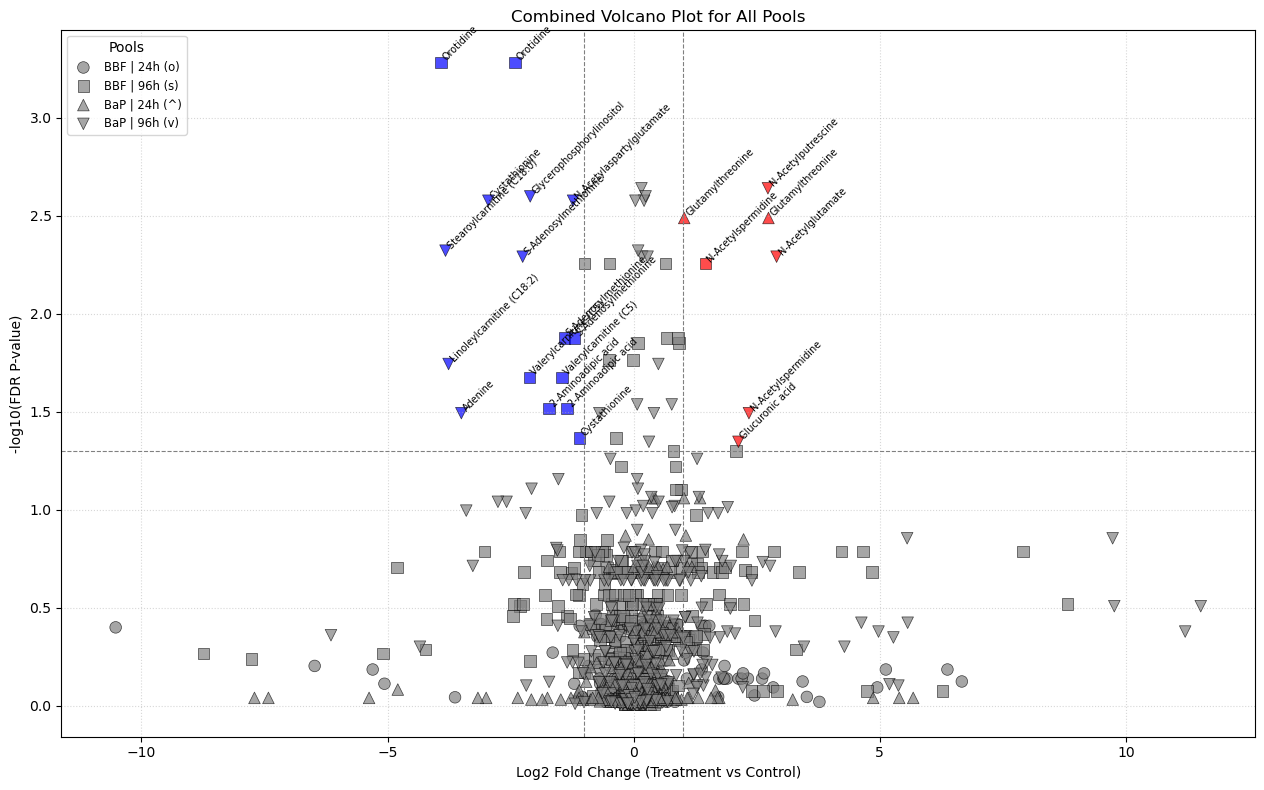

In [247]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming final_output_df is already computed and available
# It should have columns: 'Pool', 'Log2FC', 'FDR_Pval', 'Metabolite'

# Define significance thresholds
log2fc_threshold = 1.0  # Log2 fold change threshold
pval_threshold = 0.05   # FDR adjusted p-value threshold

unique_pools = final_output_df['Pool'].unique()

# Define a list of marker styles for different pools
marker_styles = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<', '>', 'p', 'h']

plt.figure(figsize=(15, 8)) # Adjusted figure size for a combined plot

for i, pool_name in enumerate(unique_pools):
    pool_data = final_output_df[final_output_df['Pool'] == pool_name].copy()

    pool_data['-log10_FDR_Pval'] = -np.log10(pool_data['FDR_Pval'].replace(0, 1e-300))
    pool_data.dropna(subset=['Log2FC', '-log10_FDR_Pval'], inplace=True)

    if pool_data.empty:
        print(f"No valid data to plot for Pool: {pool_name} after filtering.")
        continue

    conditions = [
        (pool_data['Log2FC'] > log2fc_threshold) & (pool_data['FDR_Pval'] < pval_threshold),
        (pool_data['Log2FC'] < -log2fc_threshold) & (pool_data['FDR_Pval'] < pval_threshold),
    ]
    color_choices = ['red', 'blue']
    pool_data['color'] = np.select(conditions, color_choices, default='grey')

    # Select marker style for the current pool
    marker = marker_styles[i % len(marker_styles)]

    plt.scatter(pool_data['Log2FC'], pool_data['-log10_FDR_Pval'],
                c=pool_data['color'],
                marker=marker,
                alpha=0.7,
                edgecolors='k',
                linewidths=0.5,
                s=70, # Slightly increased size for better marker visibility
                label=f"{pool_name} ({marker})" # Add pool name and marker to legend
               )

    # Annotate significant points for this pool
    significant_points = pool_data[pool_data['color'] != 'grey']
    for _, row in significant_points.iterrows():
        plt.text(row['Log2FC'], row['-log10_FDR_Pval'], str(row['Metabolite']),
                 fontsize=7, ha='left', va='bottom', alpha=1, rotation=45, color='black')

# Add threshold lines (only once for the combined plot)
plt.axvline(x=log2fc_threshold, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(x=-log2fc_threshold, color='grey', linestyle='--', linewidth=0.8)
plt.axhline(y=-np.log10(pval_threshold), color='grey', linestyle='--', linewidth=0.8)

# Add labels and title for the combined plot
plt.title('Combined Volcano Plot for All Pools')
plt.xlabel('Log2 Fold Change (Treatment vs Control)')
plt.ylabel('-log10(FDR P-value)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title="Pools", loc='upper left', fontsize='small') # Adjust legend position

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend outside
plt.show()


In [248]:
ff2 = final_output_df[final_output_df['FDR_Pval'] < 0.05].sort_values(['Pool', 'Metabolite', 'Log2FC'])
#ff2.groupby(['Pool']).count()
final_output_df.Metabolite.nunique()

148

In [249]:
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [250]:
# Combine metadata and scaled metabolite data
full_data = pd.concat([meta, log_metabo], axis=1)

# Run Tukey HSD tests for each significant (Pool, Metabolite) pair
tukey_dfs = []

for _, row in anova_df.iterrows():
    pool = row['Pool']
    metabolite = row['Metabolite']

    subset = full_data[full_data['Pool'] == pool].copy()
    if metabolite not in subset.columns:
        continue

    data = pd.DataFrame({
        'value': subset[metabolite],
        'group': subset['Group']
    })

    if data['group'].nunique() == 3:
        model = ols('value ~ C(group)', data=data).fit()

       
        tukey = pairwise_tukeyhsd(endog=data['value'], groups=data['group'], alpha=0.05)
        if metabolite == 'Orotidine':
            print(f"Running Tukey HSD for Pool: {pool}, Metabolite: {metabolite}")
            print(tukey.summary())
        tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        tukey_df['Pool'] = pool
        tukey_df['Metabolite'] = metabolite
        tukey_dfs.append(tukey_df)

# Combine all Tukey results into a single DataFrame
combined_posthoc_df = pd.concat(tukey_dfs, ignore_index=True)


Running Tukey HSD for Pool: BBF | 96h, Metabolite: Orotidine
                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
       group1                   group2           meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------------------------
BBF | 10µM BBF | 96h         BBF | 1µM BBF | 96h   0.4518 0.0007 0.2668 0.6368   True
BBF | 10µM BBF | 96h VC, BBF | 0.025% DMSO | 96h   1.1779    0.0 0.9928 1.3629   True
 BBF | 1µM BBF | 96h VC, BBF | 0.025% DMSO | 96h   0.7261    0.0  0.541 0.9111   True
-------------------------------------------------------------------------------------


In [251]:
combined_posthoc_df['p-adj'] = combined_posthoc_df['p-adj'].astype(str).astype(float)
combined_posthoc_df['reject'] = combined_posthoc_df['reject'].astype(str) 

In [252]:
combined_posthoc_df

,group1,group2,meandiff,p-adj,lower,upper,reject,Pool,Metabolite
0,BBF | 10µM BBF | 96h,BBF | 1µM BBF | 96h,0.1108,0.4321,-0.1453,0.3668,False,BBF | 96h,2-Aminoadipic acid
1,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.5186,0.0019,0.2626,0.7746,True,BBF | 96h,2-Aminoadipic acid
2,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.4078,0.0066,0.1518,0.6638,True,BBF | 96h,2-Aminoadipic acid
3,BBF | 10µM BBF | 96h,BBF | 1µM BBF | 96h,-0.2520,0.0013,-0.3679,-0.1360,True,BBF | 96h,Acetylcarnitine (C2)
4,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.2786,0.0008,-0.3946,-0.1627,True,BBF | 96h,Acetylcarnitine (C2)
...,...,...,...,...,...,...,...,...,...
64,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.2709,0.0004,-0.3725,-0.1694,True,BBF | 96h,beta-Citrylglutamate
65,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.2016,0.0022,-0.3031,-0.1000,True,BBF | 96h,beta-Citrylglutamate
66,BaP | 10µM BaP | 96h,BaP | 1µM BaP | 96h,-0.2111,0.0039,-0.3306,-0.0917,True,BaP | 96h,gamma-Butyrobetaine/deoxycarnitine
67,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-0.2327,0.0024,-0.3521,-0.1132,True,BaP | 96h,gamma-Butyrobetaine/deoxycarnitine


In [253]:
#combined_posthoc_df = combined_posthoc_df[combined_posthoc_df['p-adj']<0.01]

In [254]:
#combined_posthoc_df = combined_posthoc_df[combined_posthoc_df['reject']=='True']

In [255]:
combined_posthoc_df.Metabolite.unique()

array(['2-Aminoadipic acid', 'Acetylcarnitine (C2)', 'Adenine',
       'Cystathionine', 'Glucuronic acid', 'Glutamylthreonine',
       'Glycerophosphorylinositol', 'Hexanoylcarnitine (C6)',
       'Linoleylcarnitine (C18:2)', 'N-Acetylaspartylglutamate',
       'N-Acetylglutamate', 'N-Acetylputrescine', 'N-Acetylspermidine',
       'Orotidine', 'S-Adenosylmethionine', 'Stearoylcarnitine (C18:0)',
       'Valerylcarnitine (C5)', 'beta-Citrylglutamate',
       'gamma-Butyrobetaine/deoxycarnitine'], dtype=object)

In [256]:
combined_posthoc_df[combined_posthoc_df['Metabolite']=='Orotidine'].sort_values('Pool')

,group1,group2,meandiff,p-adj,lower,upper,reject,Pool,Metabolite
48,BBF | 10µM BBF | 96h,BBF | 1µM BBF | 96h,0.4518,0.0007,0.2668,0.6368,True,BBF | 96h,Orotidine
49,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",1.1779,0.0000,0.9928,1.3629,True,BBF | 96h,Orotidine
50,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.7261,0.0000,0.5410,0.9111,True,BBF | 96h,Orotidine


In [257]:
combined_posthoc_df.to_csv('comb.csv')

In [258]:
vc_dose_df = combined_posthoc_df[
    (combined_posthoc_df['group1'].str.startswith("VC")) ^ (combined_posthoc_df['group2'].str.startswith("VC"))].copy()
vc_dose_df.head(2)

,group1,group2,meandiff,p-adj,lower,upper,reject,Pool,Metabolite
1,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.5186,0.0019,0.2626,0.7746,True,BBF | 96h,2-Aminoadipic acid
2,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.4078,0.0066,0.1518,0.6638,True,BBF | 96h,2-Aminoadipic acid


In [259]:
def extract_comparison_info(row):
    if row['group1'].startswith("VC"):
        vc = row['group1']
        dose = row['group2']
        diff = -row['meandiff']
        print('check')
    else:
        vc = row['group2']
        dose = row['group1']
        diff = row['meandiff']
    return pd.Series({
        'VC Group': vc,
        'Dose Group': dose,
        'Signed Diff': diff,
        'Direction': '1' if diff > 0 else '-1',
        'is_significant': row['reject']
    })

# Step 3: Apply and safely avoid duplicated columns
comparison_info = vc_dose_df.apply(extract_comparison_info, axis=1)
# Drop Pool/Metabolite if they already exist in the original frame
comparison_info = comparison_info.drop(columns=['Pool', 'Metabolite'], errors='ignore')
comparison_info.head(2)

,VC Group,Dose Group,Signed Diff,Direction,is_significant
1,"VC, BBF | 0.025% DMSO | 96h",BBF | 10µM BBF | 96h,0.5186,1,True
2,"VC, BBF | 0.025% DMSO | 96h",BBF | 1µM BBF | 96h,0.4078,1,True


In [260]:
vc_dose_df1 = pd.concat([vc_dose_df, comparison_info], axis=1)
vc_dose_df1.sort_values(['Metabolite','Pool', ]).head(16)

,group1,group2,meandiff,p-adj,lower,upper,reject,Pool,Metabolite,VC Group,Dose Group,Signed Diff,Direction,is_significant
1,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.5186,0.0019,0.2626,0.7746,True,BBF | 96h,2-Aminoadipic acid,"VC, BBF | 0.025% DMSO | 96h",BBF | 10µM BBF | 96h,0.5186,1,True
2,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.4078,0.0066,0.1518,0.6638,True,BBF | 96h,2-Aminoadipic acid,"VC, BBF | 0.025% DMSO | 96h",BBF | 1µM BBF | 96h,0.4078,1,True
4,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.2786,0.0008,-0.3946,-0.1627,True,BBF | 96h,Acetylcarnitine (C2),"VC, BBF | 0.025% DMSO | 96h",BBF | 10µM BBF | 96h,-0.2786,-1,True
5,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.0267,0.7694,-0.1426,0.0893,False,BBF | 96h,Acetylcarnitine (C2),"VC, BBF | 0.025% DMSO | 96h",BBF | 1µM BBF | 96h,-0.0267,-1,False
7,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",1.0537,0.0024,0.5103,1.5972,True,BaP | 96h,Adenine,"VC, BaP | 0.1% DMSO | 96h",BaP | 10µM BaP | 96h,1.0537,1,True
8,BaP | 1µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",0.2101,0.5024,-0.3333,0.7536,False,BaP | 96h,Adenine,"VC, BaP | 0.1% DMSO | 96h",BaP | 1µM BaP | 96h,0.2101,1,False
10,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.3309,0.0026,0.1586,0.5033,True,BBF | 96h,Cystathionine,"VC, BBF | 0.025% DMSO | 96h",BBF | 10µM BBF | 96h,0.3309,1,True
11,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.1092,0.2069,-0.0631,0.2816,False,BBF | 96h,Cystathionine,"VC, BBF | 0.025% DMSO | 96h",BBF | 1µM BBF | 96h,0.1092,1,False
13,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",0.8887,0.0001,0.6214,1.1560,True,BaP | 96h,Cystathionine,"VC, BaP | 0.1% DMSO | 96h",BaP | 10µM BaP | 96h,0.8887,1,True
14,BaP | 1µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-0.0104,0.9921,-0.2777,0.2569,False,BaP | 96h,Cystathionine,"VC, BaP | 0.1% DMSO | 96h",BaP | 1µM BaP | 96h,-0.0104,-1,False


In [272]:
final_rows = []
for (pool, metabolite), group in vc_dose_df1.groupby(['Pool','Metabolite']):
    if group['Dose Group'].nunique() < 2:
        continue

    sig = group[group['is_significant'] == 'True']
    nonsig = group[group['is_significant'] == 'False']
    if len(sig) > 1 and sig['Direction'].nunique() == 1:
        final_rows.append(sig)
    elif len(sig) == 1 and len(nonsig) == 1:
        if sig['Direction'].iloc[0] == nonsig['Direction'].iloc[0]:
            final_rows.append(group)


if final_rows:
    filtered_summary = pd.concat(final_rows, ignore_index=True)[['Pool', 'Metabolite', 'Dose Group', 'VC Group', 'Signed Diff', 
                                                                 'Direction', 'is_significant']]
else:
    filtered_summary = pd.DataFrame(columns=['Pool', 'Metabolite', 'Dose Group', 'VC Group', 'Signed Diff', 'Direction', 'is_significant' ])

filtered_summary['Direction'] = -filtered_summary['Direction'].astype(int)
filtered_summary['Signed Diff'] = -filtered_summary['Signed Diff'].astype(float)
filtered_results = filtered_summary[filtered_summary.is_significant=='True']
filtered_results.sort_values(['Metabolite','Pool'])

,Pool,Metabolite,Dose Group,VC Group,Signed Diff,Direction,is_significant
0,BBF | 96h,2-Aminoadipic acid,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.5186,-1,True
1,BBF | 96h,2-Aminoadipic acid,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.4078,-1,True
2,BBF | 96h,Acetylcarnitine (C2),BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.2786,1,True
22,BaP | 96h,Adenine,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-1.0537,-1,True
4,BBF | 96h,Cystathionine,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.3309,-1,True
24,BaP | 96h,Glucuronic acid,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",0.6405,1,True
20,BaP | 24h,Glutamylthreonine,BaP | 20µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",0.8240,1,True
21,BaP | 24h,Glutamylthreonine,BaP | 2µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",0.3089,1,True
6,BBF | 96h,Glycerophosphorylinositol,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.3001,-1,True
7,BBF | 96h,Glycerophosphorylinositol,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.1487,-1,True


In [273]:
filtered_results.sort_values(['Pool'	, 'Metabolite']).to_csv('filtered.csv')

In [263]:
dfx = pd.read_csv("filtered.csv", index_col=0)
dfx.sort_values([ 'Metabolite'])

,Pool,Metabolite,Dose Group,VC Group,Signed Diff,Direction,is_significant
0,BBF | 96h,2-Aminoadipic acid,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.5186,1,True
1,BBF | 96h,2-Aminoadipic acid,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.4078,1,True
2,BBF | 96h,Acetylcarnitine (C2),BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",-0.2786,-1,True
22,BaP | 96h,Adenine,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",1.0537,1,True
4,BBF | 96h,Cystathionine,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.3309,1,True
24,BaP | 96h,Glucuronic acid,BaP | 10µM BaP | 96h,"VC, BaP | 0.1% DMSO | 96h",-0.6405,-1,True
21,BaP | 24h,Glutamylthreonine,BaP | 2µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",-0.3089,-1,True
20,BaP | 24h,Glutamylthreonine,BaP | 20µM BaP | 24h,"VC, BaP | 0.2% DMSO | 24h",-0.8240,-1,True
7,BBF | 96h,Glycerophosphorylinositol,BBF | 1µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.1487,1,True
6,BBF | 96h,Glycerophosphorylinositol,BBF | 10µM BBF | 96h,"VC, BBF | 0.025% DMSO | 96h",0.3001,1,True


In [278]:
set(dfx.Metabolite)

{'2-Aminoadipic acid',
 'Acetylcarnitine (C2)',
 'Adenine',
 'Cystathionine',
 'Glucuronic acid',
 'Glutamylthreonine',
 'Glycerophosphorylinositol',
 'Hexanoylcarnitine (C6)',
 'N-Acetylglutamate',
 'N-Acetylputrescine',
 'N-Acetylspermidine',
 'Orotidine',
 'S-Adenosylmethionine',
 'Valerylcarnitine (C5)',
 'beta-Citrylglutamate',
 'gamma-Butyrobetaine/deoxycarnitine'}

In [265]:
# Clean up column names
dfx.columns = dfx.columns.str.strip()

# Extract Chemical and Time from 'Pool' column
dfx[['Chemical', 'Time']] = dfx['Pool'].str.split('|', expand=True)
dfx['Chemical'] = dfx['Chemical'].str.strip()
dfx['Time'] = dfx['Time'].str.strip()

# Step 1: Identify all (Metabolite, Chemical) combinations that exist at 96h
valid_keys_96h = set(
    dfx[dfx['Time'] == "96h"][['Metabolite', 'Chemical']].apply(tuple, axis=1)
)
valid_keys_96h

{('2-Aminoadipic acid', 'BBF'),
 ('Acetylcarnitine (C2)', 'BBF'),
 ('Adenine', 'BaP'),
 ('Cystathionine', 'BBF'),
 ('Glucuronic acid', 'BaP'),
 ('Glycerophosphorylinositol', 'BBF'),
 ('Hexanoylcarnitine (C6)', 'BBF'),
 ('N-Acetylglutamate', 'BaP'),
 ('N-Acetylputrescine', 'BaP'),
 ('N-Acetylspermidine', 'BBF'),
 ('N-Acetylspermidine', 'BaP'),
 ('Orotidine', 'BBF'),
 ('S-Adenosylmethionine', 'BBF'),
 ('Valerylcarnitine (C5)', 'BBF'),
 ('beta-Citrylglutamate', 'BBF'),
 ('gamma-Butyrobetaine/deoxycarnitine', 'BaP')}

In [266]:

# Step 2: Filter logic
filtered_rows = []

for (metab, chem, time), group in dfx.groupby(['Metabolite', 'Chemical', 'Time']):
 
    dose_count = group['Dose Group'].nunique()
    key = (metab, chem)
    

    # Rule 2: Always keep 96h entries
    if time == "96h":
        filtered_rows.append(group)
    # Rule 3: Allow 24h only if this Metabolite+Chemical also appears at 96h
    elif time == "24h" and key in valid_keys_96h:
        filtered_rows.append(group)



final_filtered = pd.concat(filtered_rows, ignore_index=True)
final_filtered.sort_values(['Metabolite', 'Pool']).to_excel('results.xlsx')
#final_filtered[final_filtered['Metabolite']=='Pantothenic acid ']#.sort_values([ 'Metabolite', 'Chemical'	,]).drop('Unnamed: 0', axis=1)

In [274]:
# Start from the last structured DataFrame
df_check = final_filtered.copy()

# Group by Pool and Metabolite
summary_check = []

for (pool, metab), group in df_check.groupby(['Pool', 'Metabolite']):
    directions = group['Direction'].tolist()
    significance = group['is_significant'].astype(str).tolist()

    row = {
        'Pool': pool,
        'Metabolite': metab,
        'Directions': directions,
        'Significance': str(significance),
        'Both Directions Same': len(set(directions)) == 1,
        'Contains True': 'True' in significance,
        'All Significant': all(x == 'True' for x in significance)
    }
    summary_check.append(row)

check_df = pd.DataFrame(summary_check)

check_df['Significance'] = check_df['Significance'].apply(len)
check_df[check_df['Significance']==16].sort_values(['Metabolite','Pool'])

,Pool,Metabolite,Directions,Significance,Both Directions Same,Contains True,All Significant
0,BBF | 96h,2-Aminoadipic acid,"[1, 1]",16,True,True,True
3,BBF | 96h,Glycerophosphorylinositol,"[1, 1]",16,True,True,True
5,BBF | 96h,N-Acetylspermidine,"[-1, -1]",16,True,True,True
6,BBF | 96h,Orotidine,"[1, 1]",16,True,True,True
7,BBF | 96h,S-Adenosylmethionine,"[1, 1]",16,True,True,True
8,BBF | 96h,Valerylcarnitine (C5),"[1, 1]",16,True,True,True
9,BBF | 96h,beta-Citrylglutamate,"[-1, -1]",16,True,True,True


In [275]:
check_df[check_df['Significance']==16].sort_values(['Metabolite','Pool']).to_excel("check.xlsx")

In [276]:
cheklista = check_df[check_df['All Significant']].Metabolite.tolist()

In [277]:
check_df[check_df['Significance']==16].sort_values(['Metabolite','Pool']).Metabolite.to_list()

['2-Aminoadipic acid',
 'Glycerophosphorylinositol',
 'N-Acetylspermidine',
 'Orotidine',
 'S-Adenosylmethionine',
 'Valerylcarnitine (C5)',
 'beta-Citrylglutamate']